In [9]:
#생활/문화 뉴스로 그래프 그려보기
#🟠 pip install openpyxl 파이썬과 엑셀(.xlsx) 파일을 연결하는
# 1️⃣🟢1-5news_result 파일 다른이름으로 저장하여 사용
import requests
from bs4 import BeautifulSoup
import pandas as pd #1️⃣가져올 부분

# 1. 뉴스 데이터 가져오기 (네이버 검색 결과 기준) User-Agent는 사람이라고 속이는 신분증
url = 'https://news.naver.com/main/main.naver?mode=LSD&mid=shm&sid1=103'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36'}

# 1-2. url로 가서 데이터 가져와 response 변수로 대입
response = requests.get(url, headers=headers) 
soup = BeautifulSoup(response.text, 'html.parser')
titles = soup.select('.sa_text_strong') # 🟠🔴클래스명 확인! sa_text_title

# 2. 2️⃣리스트에 제목들을 담기 (기존파일 for문)
news_titles = [] 
for title in titles:
    news_titles.append(title.text)
    
# 3. 🟠3️⃣ 리스트를 Pandas의 데이터프레임(df_news) 변수로 저장 ★
# df_news 변수 저장: 단순한 글자 뭉치를 **'구조화된 표'**로 바꾸는 순간
df_news = pd.DataFrame(news_titles, columns=['생활/문화 분야 뉴스'])

# 4. 결과 확인 및 엑셀 저장 -45개
print("--- 데이터프레임 생성 완료 ---")
print(df_news.info()) # 5️⃣상위 5개 미리보기 head(), info(), describe() 뭐가 들었는지
print(df_news.isnull().sum()) #🟠빈줄 합산
# info 결측치가 아닌(Non-Null) 값이 43개 있다(결측치 있으면 40개라고 나옴)

# 5. 엑셀 파일로 내보내기 (확인 후 닫기 - 열어보고 있으면 오류🍋)
# df_news.to_excel('news_life.xlsx', index=False)
# print("--- news_life.xlsx 파일 저장 완료! ---") #\n줄바꿈

--- 데이터프레임 생성 완료 ---
<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   생활/문화 분야 뉴스  43 non-null     str  
dtypes: str(1)
memory usage: 476.0 bytes
None
생활/문화 분야 뉴스    0
dtype: int64


In [10]:
# 엑셀 파일 읽기 (파일명 오타 유의)
loaded_df = pd.read_excel('news_life.xlsx')
print("👌👌엑셀 불러오기 성공!")

👌👌엑셀 불러오기 성공!


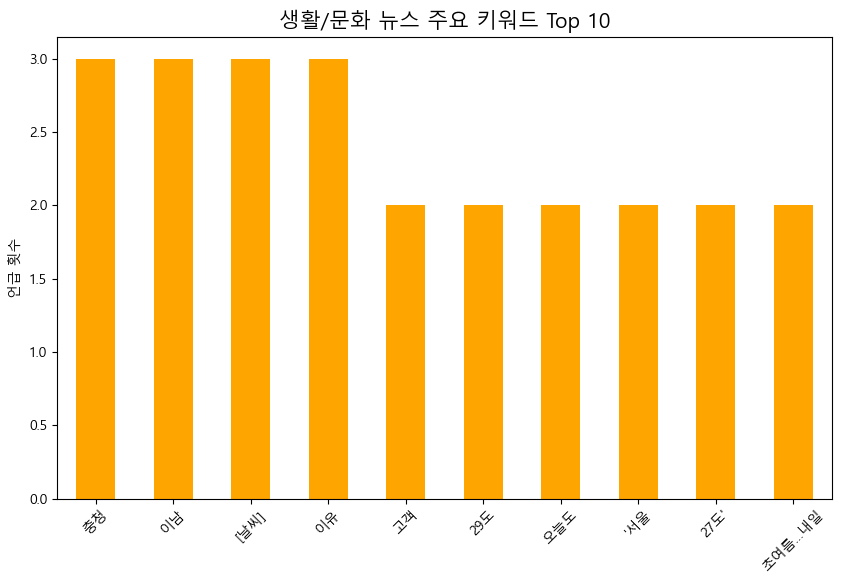

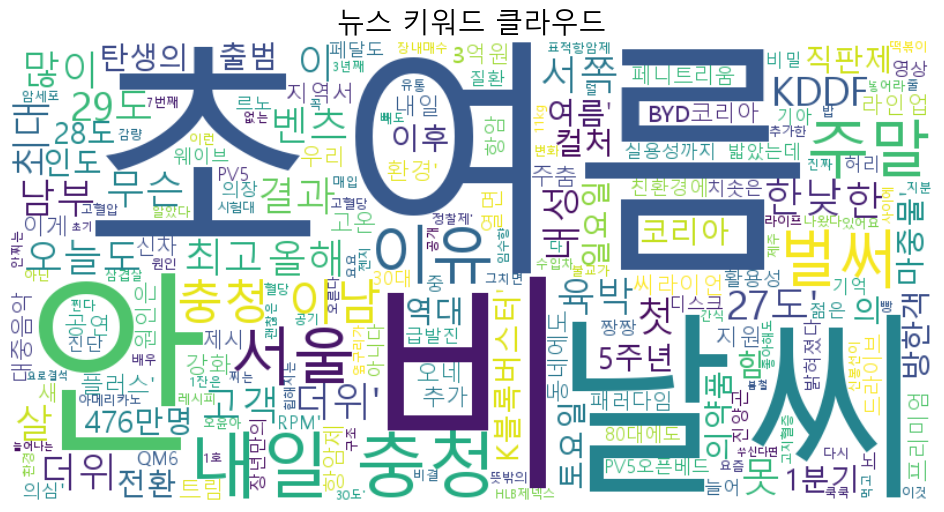

In [11]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1️⃣🟢불러온 데이터 엑셀(loaded_df)에서 개수 세기 'AI'나 '교육' 대신 다른 단어 넣어보기
# ai_count = loaded_df['IT/과학 분야 뉴스'].str.contains('AI').sum()
# python_count = loaded_df['IT/과학 분야 뉴스'].str.contains('출시').sum()

# 2️⃣1. 모든 뉴스 제목을 하나의 긴 문장으로 합치기
all_titles = " ".join(loaded_df['생활/문화 분야 뉴스'].astype(str))
# 2. 단어 단위로 쪼개기 (공백 기준)
words = all_titles.split()
# 3. 단어별 개수 세기 (Pandas Series 활용)
word_counts = pd.Series(words).value_counts()
# 4. 너무 짧은 단어(1글자)나 의미 없는 단어 제외 (전처리 실습)
# 예: '의', '가', '이' 등 제외
word_counts = word_counts[word_counts.index.str.len() > 1]
# print(f"두번째\n{word_counts}")
# 5. 상위 10개만 뽑기
top10 = word_counts.head(10)
# 6. 그래프 그리기
plt.figure(figsize=(10, 6))
top10.plot(kind='bar', color='orange')
plt.title('생활/문화 뉴스 주요 키워드 Top 10', fontsize=15)
plt.ylabel('언급 횟수')
plt.xticks(rotation=45)
plt.show()

# 3️⃣2. 워드클라우드 생성
wc = WordCloud(
    font_path='malgun',
    background_color='white',
    width=800,
    height=400
).generate(all_titles) # 위에서 합친 문장 사용

# 3. 화면에 표시
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear') #이미지쇼, 보간법 부드럽게
plt.axis('off') # 테두리 숫자(눈금) 끄기
plt.title('뉴스 키워드 클라우드', fontsize=20)
plt.show()

엑셀 오류시 설치!
pip install openpyxl